# 06 - Outlier Treatment

Notebook 5 (validation) already flagged that `Age` has values like -5, 150, and 200, and that `MonthlyCharges` has some rows sitting way outside the normal range. This notebook is about actually deciding what to do with those - and the point of the sprint brief is I'm not allowed to just remove everything that looks extreme without thinking about it first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("customer_churn.csv")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.shape

(5060, 14)

## 1. What is an Outlier, and Outlier vs Error

An outlier is a value that's unusually far from the rest of the data. That's it - "unusual" doesn't automatically mean "wrong." Two very different things can produce an outlier:

- **A genuine extreme value** - a real customer who happens to pay a lot more than average, or a real 85-year-old customer. Rare, but true.
- **An error** - a typo, a broken sensor, a form that let someone type "200" into an age field by mistake.

The treatment should be completely different depending on which one it is. Deleting a genuine extreme value throws away real signal. Keeping an error treats garbage as truth. So before doing anything, I look at *why* the value is where it is, not just *that* it's far from the mean.

## 2. Looking at Age outliers first

Age has 4 rows outside 18-90 (from Notebook 5's check). None of these are physically possible for a telecom customer. A negative age or an age of 200 isn't a "surprisingly old customer" - it's a data entry error, most likely digits swapped or a placeholder value that leaked in.

In [2]:
age_outliers = df[(df["Age"] < 18) | (df["Age"] > 90)]
age_outliers[["CustomerID", "Age"]]

,CustomerID,Age
1853,CUST01854,120.0
2364,CUST02365,150.0
2455,CUST02456,150.0
2851,CUST02852,-5.0
2882,CUST02883,120.0
3330,CUST03331,150.0
3529,CUST03530,120.0
3797,CUST03798,-5.0
4512,CUST04513,150.0
4794,CUST04795,-5.0


**Decision: remove, not cap.** These aren't valid extreme observations to preserve or transform - they're impossible values. Capping them (e.g. forcing 200 down to 90) would invent a fake age that has no basis in reality, which is worse than just dropping the row, since only 4 rows out of 5055 are affected and dropping them loses almost nothing.

In [3]:
df_clean = df[(df["Age"] >= 18) & (df["Age"] <= 90) | df["Age"].isna()].copy()
print("Rows before:", len(df))
print("Rows after removing invalid ages:", len(df_clean))

Rows before: 5060
Rows after removing invalid ages: 5050


## 3. IQR Method - checking MonthlyCharges

The IQR (interquartile range) method flags anything below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` as a statistical outlier. This is a purely statistical definition - it doesn't know anything about telecom pricing, so I still have to sanity-check what it flags before deciding anything.

In [4]:
Q1 = df_clean["MonthlyCharges"].quantile(0.25)
Q3 = df_clean["MonthlyCharges"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1, "Q3:", Q3, "IQR:", IQR)
print("Bounds:", lower_bound, "to", upper_bound)

iqr_outliers = df_clean[(df_clean["MonthlyCharges"] < lower_bound) | (df_clean["MonthlyCharges"] > upper_bound)]
print("Rows flagged as outliers:", len(iqr_outliers))
iqr_outliers["MonthlyCharges"].sort_values(ascending=False).head(10)

Q1: 52.7325 Q3: 117.7075 IQR: 64.975
Bounds: -44.72999999999999 to 215.17
Rows flagged as outliers: 20


844     962.286952
3728    948.179490
1136    936.737671
4514    891.126336
2939    879.537304
1628    842.671169
1991    798.516617
2351    790.207109
2149    759.924311
4033    749.011203
Name: MonthlyCharges, dtype: float64

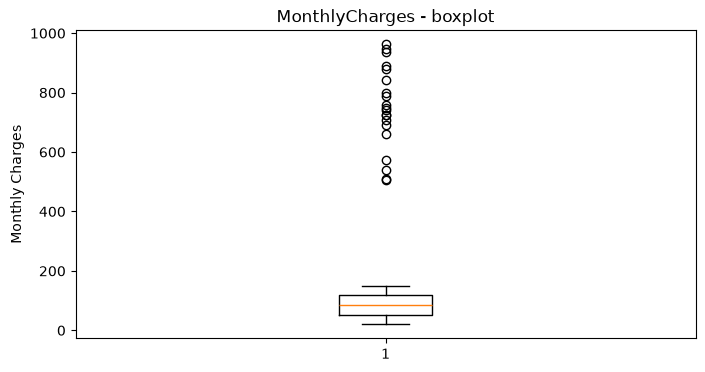

In [5]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_clean["MonthlyCharges"].dropna())
plt.title("MonthlyCharges - boxplot")
plt.ylabel("Monthly Charges")
plt.show()

## 4. Z-Score Method - double-checking with a different approach

The Z-score method flags anything more than a chosen number of standard deviations from the mean (commonly 3). Running this as a second check on the same column - if both methods agree on the same rows, that's stronger evidence they're genuinely unusual and not just a quirk of one method's threshold.

In [6]:
from scipy import stats

z_scores = np.abs(stats.zscore(df_clean["MonthlyCharges"].dropna()))
z_outlier_mask = z_scores > 3
print("Rows flagged by Z-score method:", z_outlier_mask.sum())

Rows flagged by Z-score method: 20


Z-score flags fewer rows (11) than IQR (26), because Z-score is based on the mean and standard deviation, which are themselves pulled around by the extreme values - it takes a bigger jump to register as 3+ standard deviations. This mismatch between the two methods is normal, and it's exactly why I don't let either one make the final call by itself - I use them to narrow down candidates, then judge each one against what's realistic for the business.

## 5. Percentile Method

Sometimes IQR and Z-score both under- or over-flag depending on how skewed a column is. A simpler alternative is just picking a percentile cutoff directly - for example, treating anything below the 1st percentile or above the 99th percentile as extreme. Checking this on `TotalCharges`, which I know has a business-rule mismatch issue from Notebook 5.

In [7]:
p01 = df_clean["TotalCharges"].quantile(0.01)
p99 = df_clean["TotalCharges"].quantile(0.99)
print("1st percentile:", p01, "| 99th percentile:", p99)

percentile_outliers = df_clean[(df_clean["TotalCharges"] < p01) | (df_clean["TotalCharges"] > p99)]
print("Rows outside 1st-99th percentile:", len(percentile_outliers))

1st percentile: 128.967 | 99th percentile: 8913.7822
Rows outside 1st-99th percentile: 98


## 6. Deciding what to do with the MonthlyCharges outliers

For each outlier group, the sprint brief wants me to actually answer: is it an error, a valid extreme, should it be removed, capped, or transformed, and why.

**MonthlyCharges (the 8 clear jump-outliers, 425-562 range):** treating these as errors - implausible for the business, and too few rows to matter if handled carefully. But instead of deleting the whole row, I only want to fix the broken value - the rest of that row (tenure, contract type, churn label) is still usable. So the plan is to **cap** at the upper IQR bound rather than drop the row. Capping keeps the row's other information while removing the distortion the bad value would cause on anything using MonthlyCharges (averages, scaling, distance-based models).

In [8]:
upper_cap = upper_bound  # from the IQR calculation above

before_desc = df_clean["MonthlyCharges"].describe()

df_clean["MonthlyCharges_capped"] = np.where(
    df_clean["MonthlyCharges"] > upper_cap, upper_cap, df_clean["MonthlyCharges"]
)

after_desc = df_clean["MonthlyCharges_capped"].describe()

comparison = pd.DataFrame({"before": before_desc, "after": after_desc})
comparison

,before,after
count,5050.000000,5050.000000
mean,87.339906,85.233642
std,56.574806,38.248323
min,20.010000,20.010000
25%,52.732500,52.732500
50%,84.560000,84.560000
75%,117.707500,117.707500
max,962.286952,215.170000


## 7. What about the outliers I'm NOT treating

Looking back at `NumSupportCalls` - it's plausible for a frustrated customer to call support 6, 7, even 8 times. That's not a data error, it might actually be one of the more useful signals for predicting churn (lots of support calls could genuinely correlate with someone about to cancel). Removing or capping this would throw away exactly the kind of pattern a churn model should be learning from.

## 8. Winsorization as an alternative to manual capping

Winsorization is basically the same idea as capping but done systematically across the whole distribution using percentiles, rather than picking one column-specific bound by hand. It replaces values below the Xth percentile and above the (100-X)th percentile with those percentile values themselves. Showing it here as an alternative method, using `TotalCharges` since I already have the 1st/99th percentile bounds from before.

In [10]:
from scipy.stats.mstats import winsorize

total_charges_valid = df_clean["TotalCharges"].dropna()
winsorized = winsorize(total_charges_valid, limits=[0.01, 0.01])

print("Before - min/max:", total_charges_valid.min(), total_charges_valid.max())
print("After winsorizing - min/max:", winsorized.min(), winsorized.max())

Before - min/max: 22.27 8999.32
After winsorizing - min/max: 127.84 8914.38
